# 03. Моделирование

**Цель:** сравнить несколько регрессионных алгоритмов, выбрать лучший и сохранить **одну** модель-пайплайн (предобработка + регрессор), которая принимает сырые данные.

**Метрики.**
* Основная — **MAE, кг**: средняя ошибка в понятных единицах.
* Дополнительные — RMSE (сильнее штрафует крупные промахи) и $R^2$.
* Как выяснилось - высокий $R^2$ даёт одна площадь. Поэтому сравниваем модели не только друг с другом, но и с «агрономическим» бейзлайном: *средняя урожайность с гектара × площадь*.

In [1]:
from pathlib import Path
import json
import platform

import joblib
import numpy as np
import pandas as pd
import sklearn
from IPython.display import display
from sklearn.base import clone
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import (
    GradientBoostingRegressor, 
    HistGradientBoostingRegressor, 
    RandomForestRegressor
)
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import GridSearchCV, KFold, cross_validate, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline

from modules import plots
from modules.transformers import TARGET, PerHectareRegressor

RANDOM_STATE = 42
DATA_DIR = Path("data")
MODELS_DIR = Path("models")
CV = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
plots.setup_style()

train_df = pd.read_csv(DATA_DIR / "train.csv")
X, y = train_df.drop(columns=[TARGET]), train_df[TARGET]
X_tr, X_val, y_tr, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"train: {len(X_tr)} | valid: {len(X_val)}")

preprocessor = joblib.load(MODELS_DIR / "preprocessor_fe.joblib")

train: 1496 | valid: 374


## 1. Кандидаты

Каждый кандидат — это `Pipeline([("prep", препроцессор), ("model", регрессор)])`.

Вариант **«на гектар»** — обёртка `PerHectareRegressor`. Модель учится предсказывать кг/га, а `predict` сам умножает прогноз на площадь. Это преобразование таргета, аналог `TransformedTargetRegressor`.

| Модель | Зачем в списке |
|---|---|
| `Dummy (среднее)` | нижняя планка: «модель», которая не смотрит на признаки |
| `Бейзлайн: среднее/га × площадь` | агрономическое правило без ML. Всё, что не лучше его, бесполезно |
| `Ridge`, `Ridge (на гектар)` | линейная модель с регуляризацией |
| `KNN (k=10)` | метрический метод, чувствителен к масштабу |
| `RandomForest`, `HistGradientBoosting`, `GradientBoosting` | ансамбли деревьев: пороги и взаимодействия |

In [2]:
def make_model(regressor, per_ha=False):
    pipe = Pipeline([("prep", clone(preprocessor)), ("model", regressor)])
    return PerHectareRegressor(pipe) if per_ha else pipe


candidates = {
    "Dummy (среднее)": make_model(DummyRegressor()),
    "Бейзлайн: среднее/га × площадь": make_model(DummyRegressor(), per_ha=True),
    "Ridge": make_model(Ridge(alpha=1.0)),
    "Ridge (на гектар)": make_model(Ridge(alpha=1.0), per_ha=True),
    "KNN (k=10)": make_model(KNeighborsRegressor(n_neighbors=10)),
    "RandomForest": make_model(RandomForestRegressor(
        n_estimators=300, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1
    )),
    "HistGradientBoosting": make_model(HistGradientBoostingRegressor(random_state=RANDOM_STATE)),
    "GradientBoosting": make_model(GradientBoostingRegressor(random_state=RANDOM_STATE)),
    "GradientBoosting (на гектар)": make_model(GradientBoostingRegressor(random_state=RANDOM_STATE), per_ha=True),
}

## 2. Сравнение: 5-fold CV на train + проверка на valid

In [3]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": root_mean_squared_error(y_true, y_pred),
        "R2": r2_score(y_true, y_pred)
    }


rows = []
for name, model in candidates.items():
    cv = cross_validate(model, X_tr, y_tr, cv=CV, scoring="neg_mean_absolute_error")
    val = regression_metrics(y_val, clone(model).fit(X_tr, y_tr).predict(X_val))
    rows.append({
        "модель": name,
        "CV_MAE": -cv["test_score"].mean(), 
        "CV_MAE_std": cv["test_score"].std(),
        **{f"valid_{k}": v for k, v in val.items()}
    })

results = pd.DataFrame(rows).sort_values("CV_MAE").reset_index(drop=True)
results.round(3)

,модель,CV_MAE,CV_MAE_std,valid_MAE,valid_RMSE,valid_R2
0,GradientBoosting,599.790,23.293,600.577,846.638,0.992
1,GradientBoosting (на гектар),600.209,25.131,602.483,859.269,0.991
2,Ridge (на гектар),609.083,29.953,603.761,859.728,0.991
3,Ridge,616.751,33.498,615.323,866.422,0.991
4,HistGradientBoosting,622.730,28.201,625.042,886.738,0.991
5,KNN (k=10),623.711,25.520,619.171,881.634,0.991
6,RandomForest,627.939,25.663,636.359,906.623,0.990
7,Бейзлайн: среднее/га × площадь,928.639,49.222,940.884,1132.199,0.985
8,Dummy (среднее),8026.130,296.701,8080.534,9250.365,-0.001


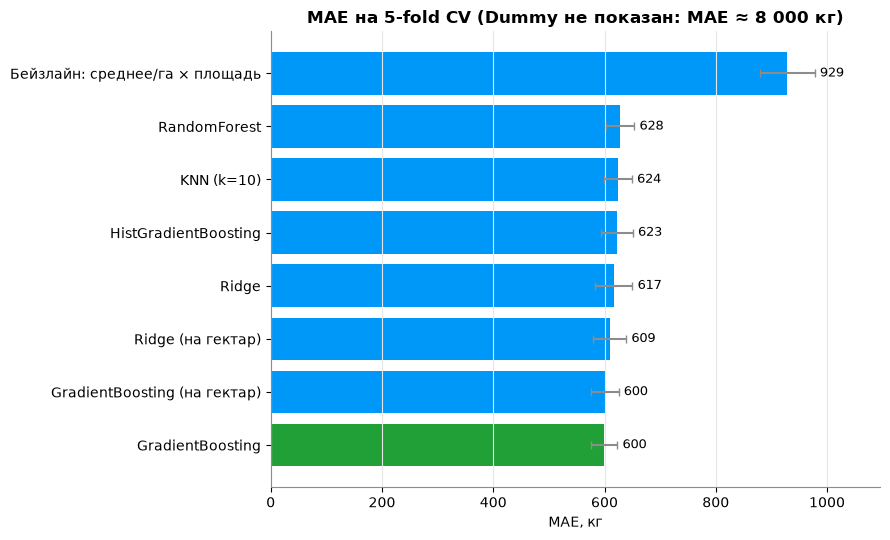

In [4]:
plots.plot_cv_comparison(
    results[results["модель"] != "Dummy (среднее)"],
    "модель", "CV_MAE", "CV_MAE_std",
    title="MAE на 5-fold CV (Dummy не показан: MAE ≈ 8 000 кг)"
)

## 3. Что показало сравнение

* **Все модели точнее бейзлайна** «среднее/га × площадь» (MAE ≈ 600–630 против 930 кг). Признаки несут реальную информацию сверх площади.
* **Лидер — `GradientBoosting`**: CV MAE ≈ 600 кг, на valid столько же. Значит, модель не переобучилась на кросс-валидации.
* `Ridge (на гектар)` отстаёт всего на ≈ 10 кг. Это простая интерпретируемая альтернатива.
* Преобразование таргета «на гектар» помогает линейной модели (617 → 609), а бустингу не нужно: деревья и так разбивают данные по площади.
* $R^2$ у всех моделей 0.990–0.992, у бейзлайна 0.985. По $R^2$ модели почти неразличимы, а по MAE разница в 1.5 раза.

## 4. Подбор гиперпараметров лидера

Небольшая сетка для `GradientBoosting`. Параметры шага адресуются через `model__...`, а `GridSearchCV` получает **весь пайплайн**.

In [5]:
param_grid = {
    "model__n_estimators": [100, 300],
    "model__learning_rate": [0.03, 0.1],
    "model__max_depth": [2, 3, 4],
    "model__min_samples_leaf": [1, 5],
}
search = GridSearchCV(
    candidates["GradientBoosting"], param_grid, cv=CV,
    scoring="neg_mean_absolute_error", n_jobs=-1
)
search.fit(X_tr, y_tr)

print("Лучшие параметры:", search.best_params_)
print(
    f"CV MAE: по умолчанию {results.loc[results['модель'] == 'GradientBoosting', 'CV_MAE'].item():.1f} → "
    f"после подбора {-search.best_score_:.1f}"
)

cv_res = pd.DataFrame(search.cv_results_).sort_values("rank_test_score").head(5)
top5 = pd.json_normalize(cv_res["params"]).rename(columns=lambda c: c.replace("model__", ""))
top5["CV_MAE"] = -cv_res["mean_test_score"].to_numpy()
top5["CV_MAE_std"] = cv_res["std_test_score"].to_numpy()
top5.round({"CV_MAE": 1, "CV_MAE_std": 1})

Лучшие параметры: {'model__learning_rate': 0.03, 'model__max_depth': 2, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
CV MAE: по умолчанию 599.8 → после подбора 593.4


,learning_rate,max_depth,min_samples_leaf,n_estimators,CV_MAE,CV_MAE_std
1,0.03,2,1,300,593.4,25.8
3,0.03,2,5,300,593.4,25.8
12,0.10,2,1,100,594.7,24.5
14,0.10,2,5,100,594.7,24.5
5,0.03,3,1,300,598.3,24.7


Подбор дал небольшое улучшение (≈ 6 кг на CV). Лучше всего работают **неглубокие деревья (`max_depth=2`) с маленьким шагом и большим числом деревьев**. Сложные взаимодействия модели не нужны.

valid после подбора: {'MAE': 588.968, 'RMSE': 839.752, 'R2': 0.992}


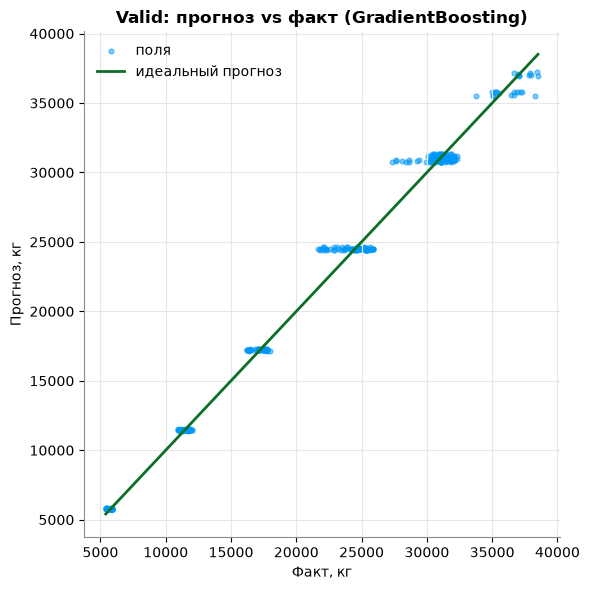

In [6]:
tuned = search.best_estimator_
val_tuned = regression_metrics(y_val, tuned.predict(X_val))
print("valid после подбора:", {k: round(v, 3) for k, v in val_tuned.items()})
plots.plot_pred_vs_true(
    y_val, tuned.predict(X_val), 
    title="Valid: прогноз vs факт (GradientBoosting)"
)

## 5. Что модель использует

Permutation importance считаем на valid **для всего пайплайна**, то есть по исходным 44 колонкам. Перемешиваем одну колонку и смотрим, насколько вырос MAE.

Колонок с нулевой важностью: 39 из 44


,"рост MAE, кг"
Hectares,9796.1
Variety,26.7
Nursery,0.7
Soil Types,0.1
Agriblock,-3.3


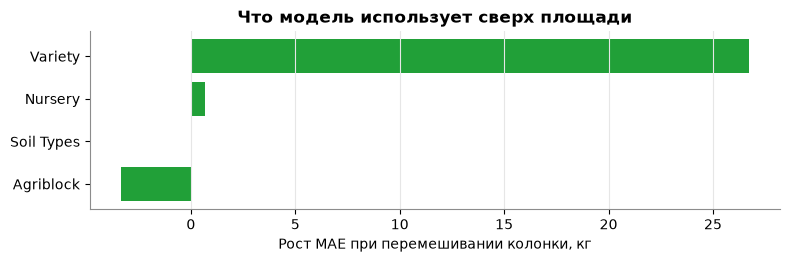

In [7]:
perm = permutation_importance(
    tuned, X_val, y_val, scoring="neg_mean_absolute_error",
    n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1
)
importance = pd.Series(
    perm.importances_mean, index=X_val.columns
).sort_values(ascending=False)
print("Колонок с нулевой важностью:", int((importance == 0).sum()), "из", len(importance))
nonzero = importance[importance != 0]
display(nonzero.round(1).to_frame("рост MAE, кг"))
plots.plot_feature_importance(
    nonzero.iloc[1:], title="Что модель использует сверх площади",
    xlabel="Рост MAE при перемешивании колонки, кг"
)

* **Площадь объясняет почти всё** (≈ 9 800 кг роста MAE при перемешивании): это пропорциональная часть урожая.
* **Сверх площади модель заметно использует только сорт** (≈ 27 кг). Вклад агроблока, почвы и питомника на valid неотличим от нуля.

## 6. Финальная модель

Гиперпараметры выбраны на train, качество подтверждено на valid. Теперь обучаем ту же конфигурацию на **всём** `train.csv` (train + valid): больше данных — точнее оценки.

In [8]:
final_model = clone(tuned).fit(X, y)
joblib.dump(final_model, MODELS_DIR / "best_model.joblib")

model_info = {
    "model": "GradientBoostingRegressor in Pipeline(preprocessor_fe)",
    "params": {k.replace("model__", ""): v for k, v in search.best_params_.items()},
    "cv_mae": round(-search.best_score_, 2),
    "valid": {k: round(v, 4) for k, v in val_tuned.items()},
    "baseline_valid_mae": round(results.loc[results["модель"].str.startswith("Бейзлайн"), "valid_MAE"].item(), 2),
    "trained_on_rows": len(X),
    "python": platform.python_version(),
    "sklearn": sklearn.__version__,
    "pandas": pd.__version__,
}
(MODELS_DIR / "model_info.json").write_text(
    json.dumps(model_info, ensure_ascii=False, indent=2)
)
print(json.dumps(model_info, ensure_ascii=False, indent=2))

{
  "model": "GradientBoostingRegressor in Pipeline(preprocessor_fe)",
  "params": {
    "learning_rate": 0.03,
    "max_depth": 2,
    "min_samples_leaf": 1,
    "n_estimators": 300
  },
  "cv_mae": 593.41,
  "valid": {
    "MAE": 588.9684,
    "RMSE": 839.7522,
    "R2": 0.9917
  },
  "baseline_valid_mae": 940.88,
  "trained_on_rows": 1870,
  "python": "3.11.0",
  "sklearn": "1.9.1",
  "pandas": "3.0.6"
}


## Итоги

* Сравнили 9 вариантов: CV по пайплайну + отдельный valid.
* Лучший — `GradientBoosting` с подобранными гиперпараметрами: CV MAE ≈ 593 кг, valid MAE ≈ 589 кг.
* `Ridge (на гектар)` почти так же точен и гораздо проще. Если важна интерпретация, это достойная замена.
* Сохранён один файл `artifacts/best_model.joblib`: на вход сырой DataFrame (как в CSV), на выходе урожай в кг.